In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


In [ ]:
import kagglehub
import tensorflow as tf
import glob
import os
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Data**

In [ ]:
manideep1108_tusimple_path = kagglehub.dataset_download('manideep1108/tusimple')

print('Data source import complete.')

100%|██████████| 21.6G/21.6G [09:40<00:00, 40.1MB/s]

Extracting files...


Data source import complete.


# **EDA**

In [ ]:
os.listdir(manideep1108_tusimple_path)

['TUSimple', 'test_label_new.json']

In [ ]:
os.listdir(os.path.join(manideep1108_tusimple_path, "TUSimple"))

['test_label.json', 'train_set', 'test_set']

In [ ]:
os.listdir(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "test_set"))

['readme.md', 'clips', 'test_tasks_0627.json']

In [ ]:
(os.listdir(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "test_set"), "clips")))

['0531', '0530', '0601']

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "test_set"), "clips"), "0530")))

1248

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "test_set"), "clips"), "0601")))

819

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "test_set"), "clips"), "0531")))

715

In [ ]:
(os.listdir(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set"), "clips")))

['0531', '0313-2', '0601', '0313-1']

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set"), "clips"), "0531")))

358

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set"), "clips"), "0601")))

410

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set"), "clips"), "0313-2")))

1503

In [ ]:
len(os.listdir(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set"), "clips"), "0313-1")))

1355

In [ ]:
# test_set/clips/0530/1492626760788443246_0/20.jpg
img = cv2.imread(os.path.join(os.path.join(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "test_set"), "clips"), "0530"), "1492626760788443246_0/20.jpg"))

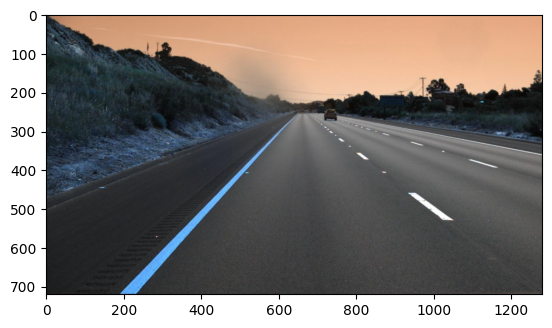

In [ ]:
plt.imshow(img)

In [ ]:
json_file = os.path.join(manideep1108_tusimple_path, "test_label_new.json")
data = []
with open(json_file , 'r') as file:
  for line in file:
    data.append(json.loads(line))


In [ ]:
len(data[0]['lanes'])

4

In [ ]:
lanes = data[0]['lanes']
h_samples = data[0]['h_samples']

In [ ]:
mask = np.zeros((720,1280), dtype=np.uint8)

In [ ]:
for lane in lanes:
  points = [[x,y] for x,y in zip(lane, h_samples) if x>=0]
  points= np.array([points], dtype=np.int32)
  cv2.polylines(mask, points, isClosed=False, color=255, thickness=5)

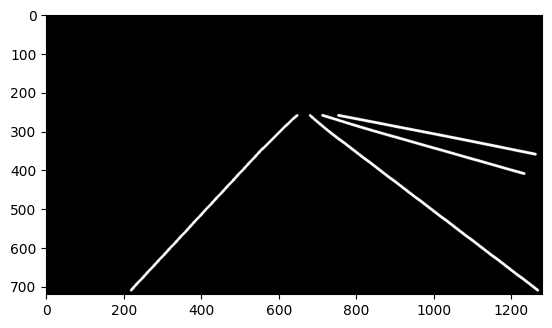

In [ ]:
plt.imshow(mask, cmap='gray')

# **Generate Masks**

In [ ]:
train_path =(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set")))

In [ ]:
os.listdir(os.path.join(os.path.join(os.path.join(manideep1108_tusimple_path, "TUSimple"), "train_set")))

['seg_label',
 'readme.md',
 'clips',
 'label_data_0601.json',
 'label_data_0313.json',
 'label_data_0531.json']

In [ ]:
lst = ["label_data_0601.json", "label_data_0313.json", "label_data_0531.json"]

In [ ]:
image_paths = []
mask_paths = []

def generate_masks(json_file_path, output_mask_dir, output_image_dir):
  if not os.path.exists(output_mask_dir):
        os.makedirs(output_mask_dir)
  data = []
  with open(json_file_path , 'r') as file:
    for line in file:
      data.append(json.loads(line))

  for data_entry in data:
    img_path = data_entry['raw_file']

    temp_image_path = os.path.join(train_path, img_path)
    image_name = img_path.replace('/', '_')
    full_image_path = os.path.join(output_image_dir, image_name)

    lanes = data_entry['lanes']
    h_samples = data_entry['h_samples']
    mask = np.zeros((720,1280), dtype=np.uint8)
    if not os.path.exists(temp_image_path):
            continue

    for lane in lanes:
      points = [[x,y] for x,y in zip(lane, h_samples) if x >= 0]
      if points:
        points = np.array([points], dtype=np.int32)
        cv2.polylines(mask, points, isClosed=False, color=255, thickness=5)

    mask_filename = image_name.replace('.jpg', '.png')
    full_mask_path = os.path.join(output_mask_dir, mask_filename)

    os.makedirs(os.path.dirname(full_mask_path), exist_ok=True)

    cv2.imwrite(full_mask_path, mask)
    shutil.copy(temp_image_path, full_image_path)

    image_paths.append(full_image_path)
    mask_paths.append(full_mask_path)
  print(f"Generated masks for {len(data)} images from {os.path.basename(json_file_path)}")
  print(f"Total images and ready-made masks: {len(image_paths)} pair.")

In [ ]:
!pwd

/content


In [ ]:
for i in lst:
    generate_masks(
        os.path.join(train_path, i),
        "/content/drive/MyDrive/Self-Driving Card Project/train/masks",
        "/content/drive/MyDrive/Self-Driving Card Project/train/images"
    )

Generated masks for 410 images from label_data_0601.json
Total images and ready-made masks: 410 pair.
Generated masks for 2858 images from label_data_0313.json
Total images and ready-made masks: 3268 pair.
Generated masks for 358 images from label_data_0531.json
Total images and ready-made masks: 3626 pair.


# **Prepare Data**

In [ ]:
images_dir = "/content/drive/MyDrive/Self-Driving Card Project/train/images/*.jpg"
masks_dir = "/content/drive/MyDrive/Self-Driving Card Project/train/masks/*.png"

image_paths = sorted(glob.glob(images_dir))
mask_paths = sorted(glob.glob(masks_dir))

In [ ]:
itrain, ival, mtrain, mval = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

In [ ]:
def load_files(image_path, mask_path):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, [256,256])
  image = image / 255.0

  mask = tf.io.read_file(mask_path)
  mask = tf.image.decode_png(mask, channels=1)
  mask = tf.image.resize(mask, [256,256])
  mask = mask / 255.0

  return image, mask

In [ ]:
def prepare_datasets(image_paths, mask_paths, batch_size=16):
  dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
  dataset = dataset.shuffle(buffer_size=1000)
  dataset = dataset.map(load_files, num_parallel_calls=tf.data.AUTOTUNE)
  dataset = dataset.batch(batch_size)
  dataset = dataset.prefetch(tf.data.AUTOTUNE)
  return dataset

In [ ]:
train_dataset = prepare_datasets(itrain, mtrain)
val_dataset = prepare_datasets(ival, mval)

In [ ]:
print(f"Number of training batches: {len(train_dataset)}")
print(f"Number of testing batches: {len(val_dataset)}")

Number of training batches: 182
Number of testing batches: 46


# **Model Building**

In [ ]:
def build_unet(input_shape = (256,256,3)):
  inputs = layers.Input(shape= input_shape)

  c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
  c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
  p1 = layers.MaxPooling2D((2,2))(c1)

  c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)
  c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c2)
  p2 = layers.MaxPooling2D((2,2))(c2)

  c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p2)
  c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c3)

  u4 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c3)
  u4 = layers.concatenate([u4, c2])
  c4 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u4)
  c4 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c4)

  u5 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c4)
  u5 = layers.concatenate([u5, c1])
  c5 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u5)
  c5 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c5)

  outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)
  return models.Model(inputs=[inputs], outputs=[outputs])


In [ ]:
model = build_unet()

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_save_path = "/content/drive/MyDrive/Self-Driving Card Project/best_unet_model.keras"

In [ ]:
checkpoint = ModelCheckpoint(
    model_save_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 128, 128,  │    131,200 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 256, 256,  │     32,832 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │    147,584 │ concatenate_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │    147,584 │ conv2d_8[0][0]  

 Total params: 2,047,361 (7.81 MB)

 Trainable params: 2,047,361 (7.81 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9736 - loss: 0.1374
Epoch 1: val_loss improved from None to 0.06433, saving model to /content/drive/MyDrive/Self-Driving Card Project/best_unet_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Self-Driving Card Project/best_unet_model.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 1600s 8s/step - accuracy: 0.9795 - loss: 0.0898 - val_accuracy: 0.9810 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 2/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.9810 - loss: 0.0607
Epoch 2: val_loss improved from 0.06433 to 0.04888, saving model to /content/drive/MyDrive/Self-Driving Card Project/best_unet_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Self-Driving Card Project/best_unet_model.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 135s 739ms/step - accuracy: 0.9813 - loss: 0.0565 - val_accuracy: 0.9820 - val_loss: 0.0489 - learning_rate: 0.0010
Epoch 3/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/ste

# **Visualizations**

In [ ]:
model_path = "/content/drive/MyDrive/Self-Driving Card Project/best_unet_model.keras"
model = models.load_model(model_path)

In [ ]:
def visualize(image_path):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, [256,256])
  image = image / 255.0
  img_ex = tf.expand_dims(image, axis=0)
  print(img_ex.shape)
  pred = model.predict(img_ex)[0]
  pred_mask = (pred > 0.5).astype(np.float32)
  img = image.numpy()
  mask = np.zeros_like(img)
  mask[:,:,0] = pred_mask[:,:,0]
  con = cv2.addWeighted(img, 1.0, mask, 0.7, 0)

  plt.figure(figsize=(18,6))

  plt.subplot(1,3,1)
  plt.title("Original", fontsize=16)
  plt.imshow(img)

  plt.subplot(1, 3, 2)
  plt.title("Predicted Mask", fontsize=16)
  plt.imshow(mask, cmap='gray')

  plt.subplot(1, 3, 3)
  plt.title("Result", fontsize=16)
  plt.imshow(con)
  plt.show()

(1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


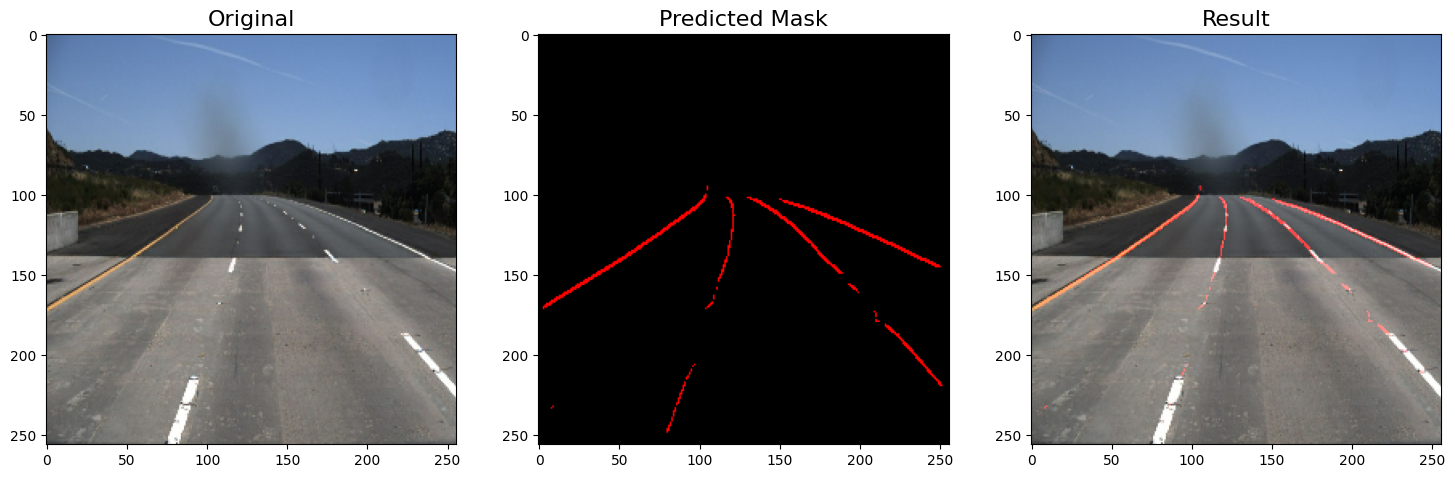

In [ ]:
visualize(random.choice(ival))

# **Object Detection with YOLO (You Only Look Once)**

In [ ]:
yolo_model = YOLO('yolov8n.pt')

In [ ]:
def driving(image_path, model):
  img = cv2.imread(image_path)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  h, w, _ = img_rgb.shape
  results = yolo_model(img_rgb)
  boxes = results[0].plot()
  img = cv2.resize(img_rgb, (256, 256))
  img = img / 255.0
  img = tf.expand_dims(img, axis=0)
  pred = model.predict(img)[0]
  pred_mask = (pred > 0.5).astype(np.uint8)
  mask_resized = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)
  mask = np.zeros_like(boxes)
  mask[:,:,0] = mask_resized * 255
  final = cv2.addWeighted(boxes, 1.0, mask, 0.7, 0)

  plt.figure(figsize=(10, 8))
  plt.imshow(final)
  plt.show()


0: 384x640 5 cars, 7.1ms
Speed: 2.3ms preprocess, 7.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


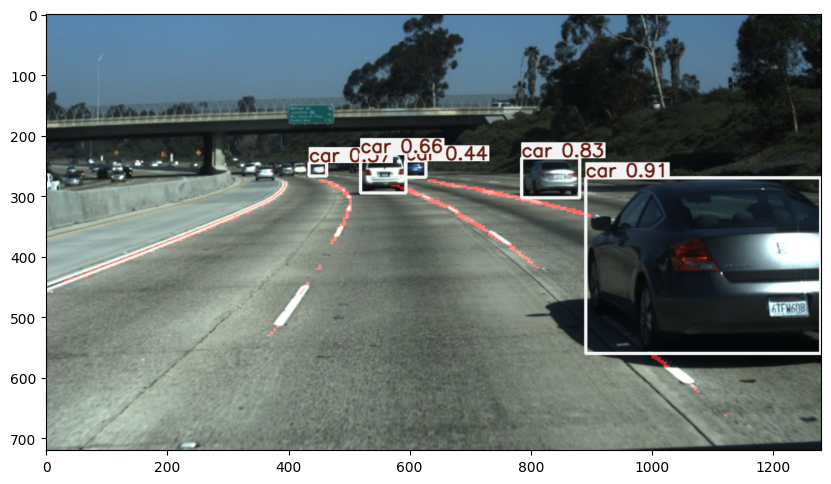

In [ ]:
random_image = random.choice(ival)
driving(random_image, model)